# Path Generation — Manual Testing

This notebook walks through the `ScenarioEngine` path generation step by step.
The goal is to visually inspect and sanity-check:
- Are paths shaped correctly (drift, shock, recovery)?
- Does correlation between underlyings look right?
- Do multi-shock paths behave as expected?
- Are final spots and payoffs sensible?

In [1]:
import sys
from pathlib import Path

# make src and data importable
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.scenario_engine import ScenarioEngine
from src.reverse_convertible import ReverseConvertible
from data.portfolio import portfolio
from data.reference_data import beta_map, vol_map, isin_ticker_map

pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 1. Setup — pick a single product to test on

We start with the simplest case: a single-underlying BRC (p1 — ALCON).
Once we're happy with that we'll move to the multi-underlying MBRC.

In [2]:
# BRC — single underlying (ALCON)
row_brc = portfolio[portfolio['product_id'] == 'CH1483491150'].iloc[0]

# MBRC — 4 underlyings (ABB, HOLCIM, NOVARTIS, ROCHE)
row_mbrc = portfolio[portfolio['product_id'] == 'CH1449111066'].iloc[0]

print('BRC underlyings :', row_brc['underlyings'])
print('BRC spots       :', row_brc['current_spots'])
print('BRC strike      :', row_brc['strike'])
print('BRC barrier_pct :', row_brc['barrier_pct'])
print()
print('MBRC underlyings:', row_mbrc['underlyings'])
print('MBRC spots      :', row_mbrc['current_spots'])
print('MBRC strikes    :', row_mbrc['strike'])

BRC underlyings : ['ALCON']
BRC spots       : [58.76]
BRC strike      : [59.72]
BRC barrier_pct : 0.7

MBRC underlyings: ['ABB', 'HOLCIM', 'NOVARTIS', 'ROCHE']
MBRC spots      : [34.0, 68.0, 92.0, 245.0]
MBRC strikes    : [35.0, 70.0, 90.0, 250.0]


In [3]:
engine = ScenarioEngine(portfolio=portfolio, beta_map=beta_map, vol_map=vol_map)
print('Engine created')

Engine created


## 2. Flat scenario — no shock, no drift

With zero shock and zero drift, prices should stay roughly flat around the starting spot.
Any movement is purely from the GBM diffusion term (volatility).
This is a basic sanity check that the simulation is running.

In [4]:
scenario_flat = {
    'market_shock'      : 0,
    'n_shocks'          : 1,
    'shock_in_days'     : 2,
    'shock_spacing_days': 0,
    'pre_shock_drift_pa': 0.0,
    'post_shock_drift_pa': 0.0,
}

shocks, final_spots, T_rem, summary, paths = engine.build_shock_paths(row_brc, scenario_flat)

print('Path summary:')
for k, v in summary.items():
    print(f'  {k}: {v}')
print()
print('Starting spot :', row_brc['current_spots'][0])
print('Final spot    :', final_spots[0])
print('Shock % actual:', round(shocks[0], 2), '%')

Path summary:
  maturity_date: 2026-11-17
  T_remaining_years: 0.611
  T_first_shock_years: 0.006
  T_post_shock_years: 0.719
  effective_n_shocks: 1
  market_shock_pct: 0
  pre_shock_drift_pa: 0.0
  post_shock_drift_pa: 0.0
  correlation_used: True

Starting spot : 58.76
Final spot    : 71.5239
Shock % actual: 21.72 %


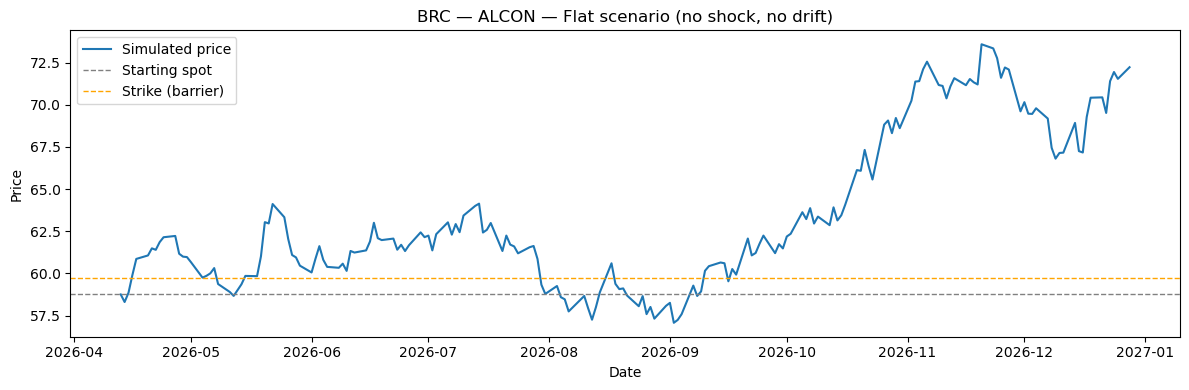

In [5]:
isin = row_brc['underlying_isins'][0]
path_df = paths[isin]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(path_df['date'], path_df['price'], lw=1.5, label='Simulated price')
ax.axhline(row_brc['current_spots'][0], color='grey', linestyle='--', lw=1, label='Starting spot')
ax.axhline(row_brc['strike'][0], color='orange', linestyle='--', lw=1, label='Strike (barrier)')
ax.set_title('BRC — ALCON — Flat scenario (no shock, no drift)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Shock scenario — down 20%

We expect to see:
- A smooth drift upward before the shock date
- A sharp discrete drop on the shock date
- A recovery drift after the shock

The shock is applied as a flat % to the price, not beta-scaled.

Starting spot : 58.76
Final spot    : 58.5333
Shock % actual: -0.39 %


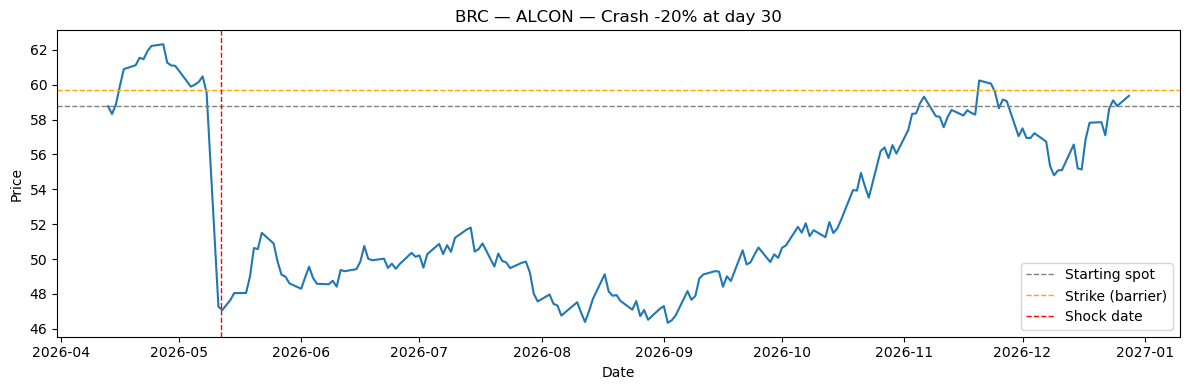

In [6]:
scenario_crash = {
    'market_shock'      : -20,
    'n_shocks'          : 1,
    'shock_in_days'     : 30,
    'shock_spacing_days': 0,
    'pre_shock_drift_pa': 0.05,
    'post_shock_drift_pa': 0.05,
}

shocks, final_spots, T_rem, summary, paths = engine.build_shock_paths(row_brc, scenario_crash)

print('Starting spot :', row_brc['current_spots'][0])
print('Final spot    :', final_spots[0])
print('Shock % actual:', round(shocks[0], 2), '%')

isin = row_brc['underlying_isins'][0]
path_df = paths[isin]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(path_df['date'], path_df['price'], lw=1.5)
ax.axhline(row_brc['current_spots'][0], color='grey', linestyle='--', lw=1, label='Starting spot')
ax.axhline(row_brc['strike'][0], color='orange', linestyle='--', lw=1, label='Strike (barrier)')
shock_date = pd.Timestamp.today() + pd.Timedelta(days=30)
ax.axvline(shock_date, color='red', linestyle='--', lw=1, label='Shock date')
ax.set_title('BRC — ALCON — Crash -20% at day 30')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multi-shock scenario

Two shocks spaced 30 days apart. We expect two discrete drops.

Effective shocks applied: 2
Starting spot : 58.76
Final spot    : 59.265


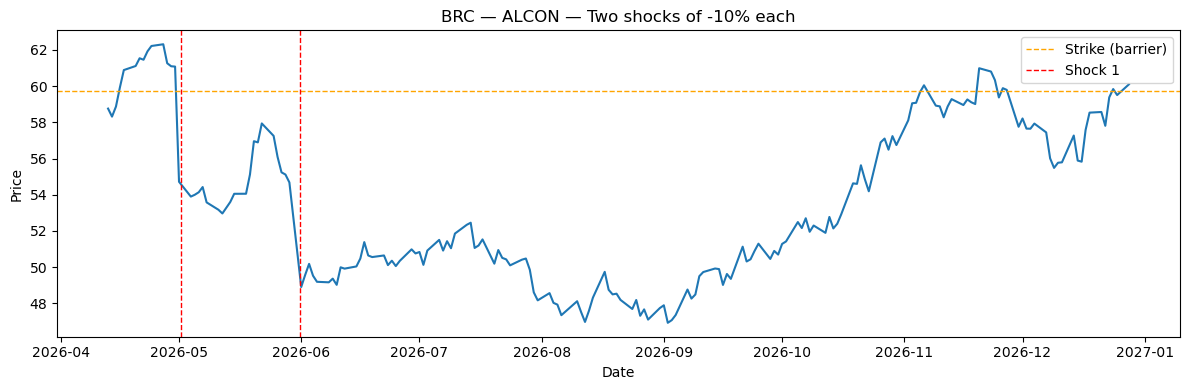

In [7]:
scenario_multi_shock = {
    'market_shock'      : -10,
    'n_shocks'          : 2,
    'shock_in_days'     : 20,
    'shock_spacing_days': 30,
    'pre_shock_drift_pa': 0.05,
    'post_shock_drift_pa': 0.05,
}

shocks, final_spots, T_rem, summary, paths = engine.build_shock_paths(row_brc, scenario_multi_shock)

print('Effective shocks applied:', summary['effective_n_shocks'])
print('Starting spot :', row_brc['current_spots'][0])
print('Final spot    :', final_spots[0])

isin = row_brc['underlying_isins'][0]
path_df = paths[isin]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(path_df['date'], path_df['price'], lw=1.5)
ax.axhline(row_brc['strike'][0], color='orange', linestyle='--', lw=1, label='Strike (barrier)')
for i in range(2):
    sd = pd.Timestamp.today() + pd.Timedelta(days=20 + i * 30)
    ax.axvline(sd, color='red', linestyle='--', lw=1, label=f'Shock {i+1}' if i == 0 else '_')
ax.set_title('BRC — ALCON — Two shocks of -10% each')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

## 5. MBRC — correlated paths

For the 4-underlying MBRC we want to check:
- All 4 paths are plotted together
- They move in the same direction on shock dates (they share the same discrete shock)
- Their day-to-day GBM diffusion is correlated according to the correlation matrix
- The worst-of underlying is identified correctly at maturity

Final spots per underlying:
  ABB         start=34.00  final=23.66  perf=-30.40%
  HOLCIM      start=68.00  final=55.22  perf=-18.80%
  NOVARTIS    start=92.00  final=86.96  perf=-5.48%
  ROCHE       start=245.00  final=244.85  perf=-0.06%


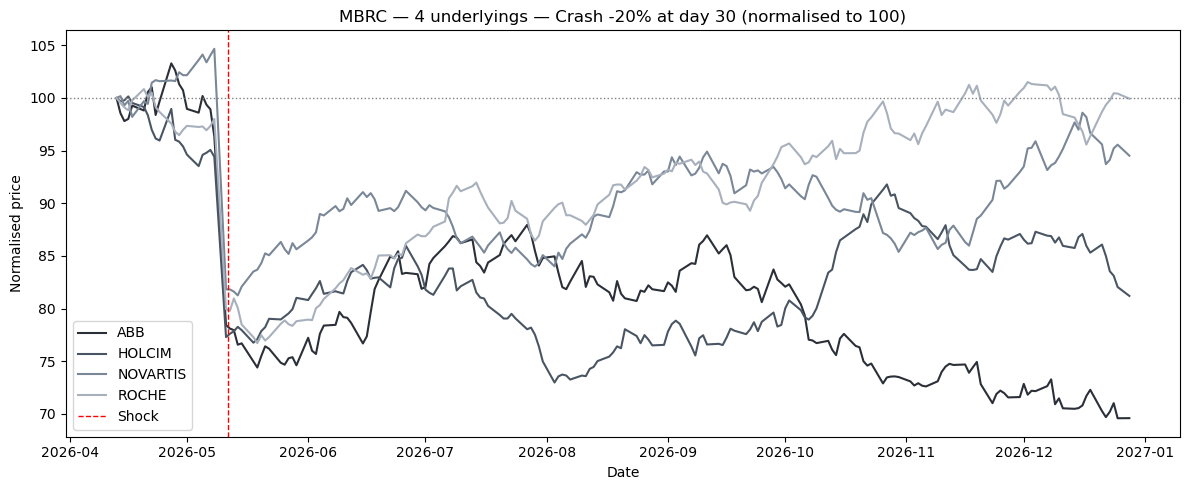

In [8]:
# Build a simple identity correlation matrix (independent) first
n = len(row_mbrc['underlying_isins'])
corr_identity = np.eye(n)

scenario_crash = {
    'market_shock'      : -20,
    'n_shocks'          : 1,
    'shock_in_days'     : 30,
    'shock_spacing_days': 0,
    'pre_shock_drift_pa': 0.05,
    'post_shock_drift_pa': 0.05,
}

shocks, final_spots, T_rem, summary, paths = engine.build_shock_paths(
    row_mbrc, scenario_crash, corr_matrix=corr_identity
)

print('Final spots per underlying:')
for name, isin, spot, final in zip(
    row_mbrc['underlyings'],
    row_mbrc['underlying_isins'],
    row_mbrc['current_spots'],
    final_spots
):
    perf = (final / spot - 1) * 100
    print(f'  {name:10s}  start={spot:.2f}  final={final:.2f}  perf={perf:+.2f}%')

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2A2F38', '#4A5563', '#7A8797', '#A7B0BC']
for (name, isin), color in zip(zip(row_mbrc['underlyings'], row_mbrc['underlying_isins']), colors):
    path_df = paths[isin]
    # normalise to 100 for comparability
    norm = path_df['price'] / path_df['price'].iloc[0] * 100
    ax.plot(path_df['date'], norm, lw=1.5, label=name, color=color)
ax.axvline(pd.Timestamp.today() + pd.Timedelta(days=30), color='red', linestyle='--', lw=1, label='Shock')
ax.axhline(100, color='grey', linestyle=':', lw=1)
ax.set_title('MBRC — 4 underlyings — Crash -20% at day 30 (normalised to 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised price')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Effect of correlation on paths

Compare two runs:
- **Identity matrix** (independent assets) — paths diverge freely
- **High correlation matrix** (all 0.9) — paths move closely together

With high correlation we expect the paths to look much more similar to each other.

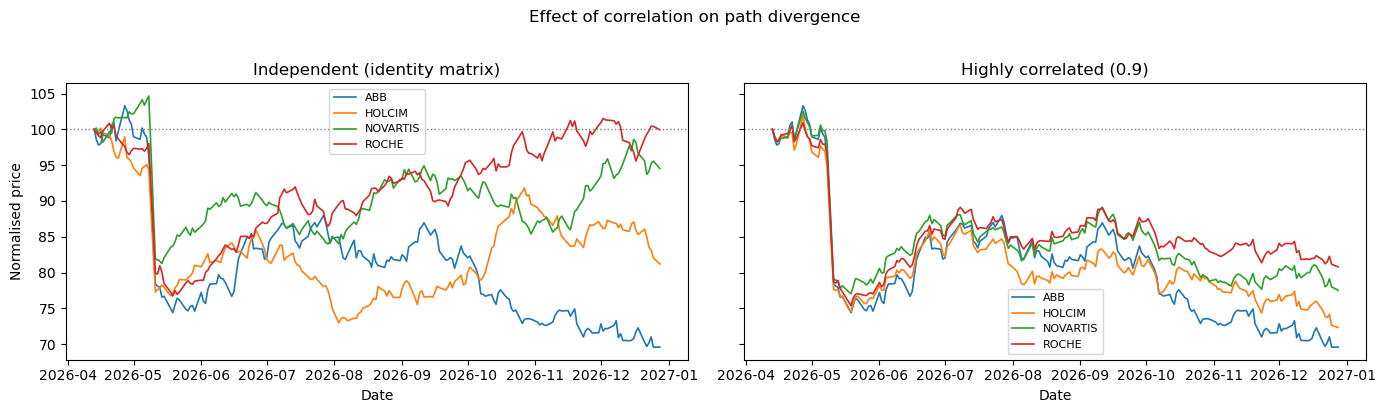

In [9]:
n = len(row_mbrc['underlying_isins'])
corr_high = np.full((n, n), 0.9)
np.fill_diagonal(corr_high, 1.0)

_, _, _, _, paths_indep = engine.build_shock_paths(row_mbrc, scenario_crash, corr_matrix=np.eye(n))
_, _, _, _, paths_corr  = engine.build_shock_paths(row_mbrc, scenario_crash, corr_matrix=corr_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, paths_dict, title in [
    (axes[0], paths_indep, 'Independent (identity matrix)'),
    (axes[1], paths_corr,  'Highly correlated (0.9)'),
]:
    for name, isin in zip(row_mbrc['underlyings'], row_mbrc['underlying_isins']):
        df = paths_dict[isin]
        norm = df['price'] / df['price'].iloc[0] * 100
        ax.plot(df['date'], norm, lw=1.2, label=name)
    ax.axhline(100, color='grey', linestyle=':', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Normalised price')
plt.suptitle('Effect of correlation on path divergence', y=1.02)
plt.tight_layout()
plt.show()

## 7. Payoff check — does the scenario produce the right settlement?

Run the full `run_product_path_scenario` and inspect:
- Was the barrier breached?
- What is the worst-of underlying?
- Is settlement cash or physical?
- Does the PnL make sense given the final spots?

In [10]:
scenario_crash = {
    'market_shock'      : -20,
    'n_shocks'          : 1,
    'shock_in_days'     : 30,
    'shock_spacing_days': 0,
    'pre_shock_drift_pa': 0.05,
    'post_shock_drift_pa': 0.05,
}

res = engine.run_product_path_scenario(row_mbrc, scenario_crash)

print(f"Product        : {res['product_id']}")
print(f"Barrier breached: {res['barrier_breached']}")
print(f"Worst underlying: {res['worst_underlying']}")
print(f"Settlement type : {res['settlement_type']}")
print(f"Total cost      : {res['total_cost']:,.2f}")
print(f"Total payoff    : {res['total_payoff']:,.2f}")
print(f"PnL             : {res['pnl']:,.2f}")
print(f"Return          : {res['return_pct']*100:.2f}%")
print()
print('Final spots per underlying:')
for name, isin, spot, final in zip(
    row_mbrc['underlyings'],
    row_mbrc['underlying_isins'],
    row_mbrc['current_spots'],
    res['final_spots']
):
    strike = row_mbrc['strike'][row_mbrc['underlyings'].index(name)]
    perf = (final / spot - 1) * 100
    breached = final < strike
    print(f'  {name:10s}  start={spot:.2f}  final={final:.4f}  perf={perf:+.2f}%  strike={strike:.2f}  breached={breached}')

Product        : CH1449111066
Barrier breached: True
Worst underlying: ABB
Settlement type : physical
Total cost      : 980.00
Total payoff    : 744.16
PnL             : -235.84
Return          : -24.07%

Final spots per underlying:
  ABB         start=34.00  final=23.6633  perf=-30.40%  strike=35.00  breached=True
  HOLCIM      start=68.00  final=55.2185  perf=-18.80%  strike=70.00  breached=True
  NOVARTIS    start=92.00  final=86.9580  perf=-5.48%  strike=90.00  breached=True
  ROCHE       start=245.00  final=244.8466  perf=-0.06%  strike=250.00  breached=True


## 8. Determinism check

Running the same scenario twice should produce identical paths.
Running two different scenarios should produce different paths.

In [11]:
_, _, _, _, paths_run1 = engine.build_shock_paths(row_brc, scenario_crash)
_, _, _, _, paths_run2 = engine.build_shock_paths(row_brc, scenario_crash)

isin = row_brc['underlying_isins'][0]
identical = (paths_run1[isin]['price'].values == paths_run2[isin]['price'].values).all()
print(f'Same scenario run twice → identical paths: {identical}')  # expect True

scenario_other = {**scenario_crash, 'market_shock': -10}
_, _, _, _, paths_other = engine.build_shock_paths(row_brc, scenario_other)
different = (paths_run1[isin]['price'].values != paths_other[isin]['price'].values).any()
print(f'Different scenario → different paths     : {different}')  # expect True

Same scenario run twice → identical paths: True
Different scenario → different paths     : True


## 9. Scratch space

Use this cell for any ad-hoc checks.

In [ ]:
# your checks here
